# Premier League match-outcome predictor — walkthrough

This notebook walks through the whole project end to end: **data → features → ratings → models → predictions**.
It uses the package in `src/epl_predictor`, so every step here is the same code the CLI runs.

The task: before kick-off, predict whether the **home team wins, it's a draw, or the away team wins**,
using nothing but what happened in earlier matches.

In [1]:
import sys, json, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from epl_predictor import config
from epl_predictor.data import get_matches
from epl_predictor.features import get_features, feature_columns
from epl_predictor.evaluate import SERIES, INK2   # shared chart style (applied on import)

pd.set_option("display.width", 140, "display.max_columns", 30)

## 1. Data

33 seasons (1993/94 → 2025/26) of Premier League results from football-data.co.uk, via a GitHub mirror.
Match statistics (shots, shots on target, corners, fouls, cards) are available from **2000/01** onward.

In [2]:
matches = get_matches()
print(f"{len(matches):,} matches, {matches.Season.nunique()} seasons, {matches.Date.min().date()} → {matches.Date.max().date()}")
matches.tail(3)

12,704 matches, 33 seasons, 1993-08-14 → 2026-05-24


,match_id,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,Season
12701,12701,2026-05-24,Sunderland,Chelsea,2,1,H,1.0,0.0,H,C Kavanagh,20.0,10.0,2.0,1.0,15.0,18.0,7.0,7.0,3.0,2.0,0.0,0.0,2025
12702,12702,2026-05-24,Tottenham,Everton,1,0,H,1.0,0.0,H,M Oliver,21.0,8.0,6.0,3.0,15.0,12.0,6.0,2.0,5.0,3.0,0.0,1.0,2025
12703,12703,2026-05-24,West Ham,Leeds,3,0,H,0.0,0.0,D,A Taylor,16.0,13.0,9.0,3.0,11.0,14.0,6.0,4.0,0.0,3.0,0.0,0.0,2025


In [3]:
share = matches.groupby("Season")["FTR"].value_counts(normalize=True).unstack()[["H", "D", "A"]]
fig, ax = plt.subplots(figsize=(10, 3.8))
for col, label, c in zip(["H", "D", "A"], ["Home win", "Draw", "Away win"], SERIES[:3]):
    ax.plot(share.index, share[col], color=c, label=label)
ax.set_title("Result shares by season — the home-advantage baseline the model has to beat")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=0))
ax.legend(ncol=3); plt.show()
print(f"Overall: home {share['H'].mean():.1%}  draw {share['D'].mean():.1%}  away {share['A'].mean():.1%}")

Overall: home 45.7%  draw 25.5%  away 28.8%


Home teams win ~45% of matches, so "always predict a home win" is already 45% accurate.
That is the floor. Bookmakers, who use far more information than we have, land around 55%.

## 2. Features (all computed *before* kick-off)

`features.py` builds ~280 pre-match features per fixture. Everything is derived from earlier matches only:

| family | examples |
|---|---|
| **Ratings** | Elo (margin-of-victory, season regression), *performance* Elo driven by shots-on-target share, pi-ratings (home/away specific) |
| **Form** | rolling 5/10-match and exponentially-weighted goals, shots, shots on target, corners, points; shot-share ratios (TSR/STR) as possession proxies; momentum vs. 38-match baseline |
| **Venue form** | home team's last 5 *home* games, away team's last 5 *away* games, team-specific home advantage |
| **Season context** | points per game, goal difference, league position and gap to top, previous-season finish, promoted flag |
| **Match-up** | Poisson expected goals (attack × opponent defence × league rate) → P(H/D/A); attack-vs-defence differentials |
| **Head-to-head** | record over the last 6 meetings, and at this venue |
| **Schedule** | rest days, fixtures in the last 14 days, unbeaten/winless streaks |
| **League environment** | rolling home-win rate, draw rate, goals per game (captures e.g. the empty-stadium 2020/21 season) |

In [4]:
feats = get_features()
cols = feature_columns(feats)
print(f"{len(cols)} features for {len(feats):,} matches")
example = feats[feats.Season == 2025].iloc[-1]
print(f"Example: {example.HomeTeam} v {example.AwayTeam} on {example.Date.date()}  (result {example.FTHG:.0f}-{example.FTAG:.0f})")
example[["elo_home", "elo_away", "elo_exp_home", "pelo_diff", "pi_exp_gd", "poisv_exp_hg", "poisv_exp_ag",
         "h_pts_r5", "a_pts_r5", "h_league_pos", "a_league_pos", "h2h_home_gd", "h_rest_days", "a_rest_days"]].round(3)

281 features for 12,704 matches
Example: West Ham v Leeds on 2026-05-24  (result 3-0)


elo_home        1436.929
elo_away        1467.207
elo_exp_home       0.543
pelo_diff        -32.822
pi_exp_gd          0.131
poisv_exp_hg       1.568
poisv_exp_ag       1.419
h_pts_r5             0.8
a_pts_r5             2.2
h_league_pos        18.0
a_league_pos        14.0
h2h_home_gd          0.5
h_rest_days          7.0
a_rest_days          7.0
Name: 12703, dtype: object

In [5]:
train_rows = feats[feats.Season >= config.TRAIN_FROM_SEASON]
gd = train_rows.FTHG - train_rows.FTAG
corr = train_rows[cols].corrwith(gd).sort_values(key=abs, ascending=False).head(20)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(corr.index[::-1], corr.values[::-1], color=[SERIES[0] if v > 0 else SERIES[7] for v in corr.values[::-1]], height=0.7)
ax.set_title("Features most correlated with the final goal difference (home − away)")
ax.grid(axis="y", visible=False); plt.show()

No single feature gets above |r| ≈ 0.45 — football is noisy, and that is what caps the achievable accuracy.
Notice that the *shot-based* performance Elo (`pelo_diff`) is as informative as result-based Elo.

### Elo ratings over time

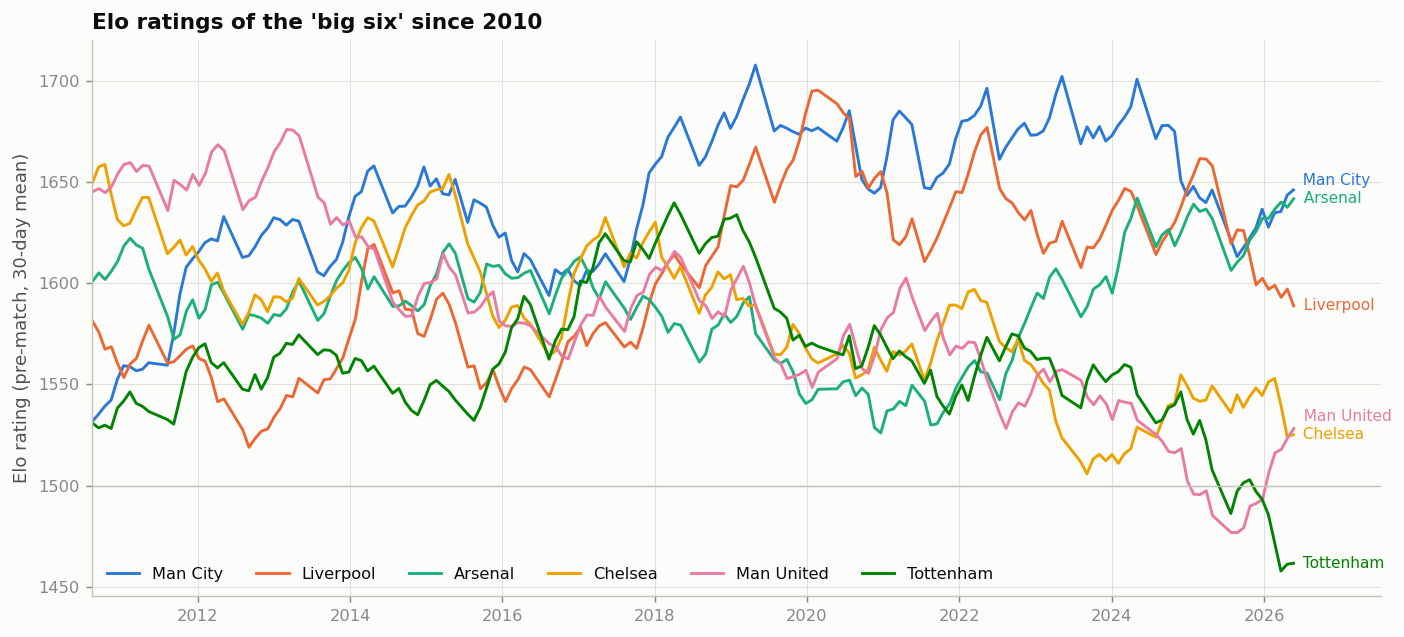

In [6]:
display(Image('../reports/figures/elo_history.png'))

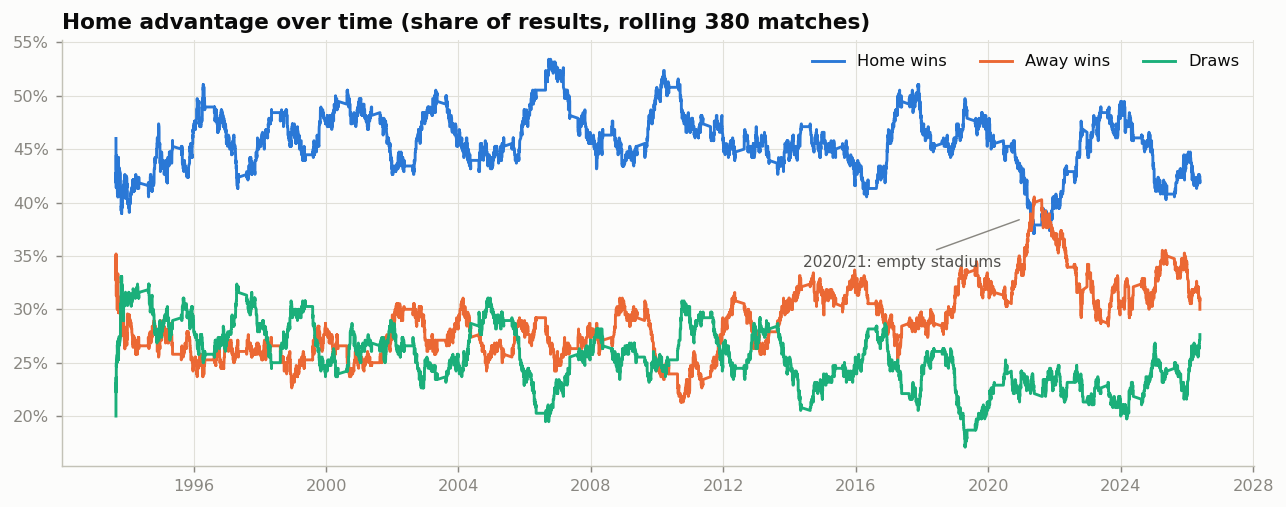

In [7]:
display(Image('../reports/figures/home_advantage.png'))

## 3. Models and evaluation protocol

* **Training rows:** seasons 2002/03 onward (two seasons of shot data warm the rolling stats up).
* **Cross-validation:** expanding window over the six seasons 2018/19 – 2023/24: train on every earlier season, predict that one.
  This is exactly how the model would be used in practice, and it is the only honest way to validate time-series data.
* **Hold-out:** 2024/25 and 2025/26 were never touched during tuning or model selection.
* **Models:** class-prior and Elo-only baselines, a compact "ratings" logistic regression, full logistic regression,
  random forest, **XGBoost (Optuna-tuned)**, LightGBM, and a weighted probability-averaging **ensemble**.
* **Metrics:** accuracy (what you asked for), plus log loss, Brier score and the ranked probability score (RPS) —
  the standard scoring rule for football forecasts, which rewards probabilities that are *close* to the truth.

In [8]:
metrics = json.loads((Path.cwd().parent / "models" / "metrics.json").read_text())
cv = pd.DataFrame(metrics["cv_summary"]).sort_values("log_loss")
holdout = pd.DataFrame(metrics["holdout"]).sort_values("log_loss")
print("Cross-validation (mean over six seasons)"); display(cv.round(4))
print("Hold-out 2024/25 + 2025/26 (760 matches)"); display(holdout.round(4))
print("Deployed model:", metrics["deployed"])

Cross-validation (mean over six seasons)


,accuracy,log_loss,brier,rps
xgboost,0.5513,0.9596,0.5672,0.1987
ratings_logit,0.5513,0.9608,0.5684,0.1993
ensemble,0.5518,0.9615,0.5682,0.1990
random_forest,0.5513,0.9658,0.5706,0.1998
elo_logit,0.5452,0.9680,0.5726,0.2013
lightgbm,0.5456,0.9717,0.5741,0.2011
logreg,0.5439,0.9774,0.5760,0.2016
prior,0.4469,1.0653,0.6445,0.2358


Hold-out 2024/25 + 2025/26 (760 matches)


,accuracy,log_loss,brier,rps
ratings_logit,0.5105,1.0079,0.6042,0.2059
ensemble,0.5026,1.0092,0.6049,0.2058
random_forest,0.5079,1.0111,0.6055,0.2060
xgboost,0.5118,1.0115,0.6059,0.2061
logreg,0.5000,1.0137,0.6080,0.2069
elo_logit,0.4947,1.0187,0.6116,0.2100
lightgbm,0.5039,1.0210,0.6125,0.2084
prior,0.4171,1.0836,0.6569,0.2324


Deployed model: xgboost


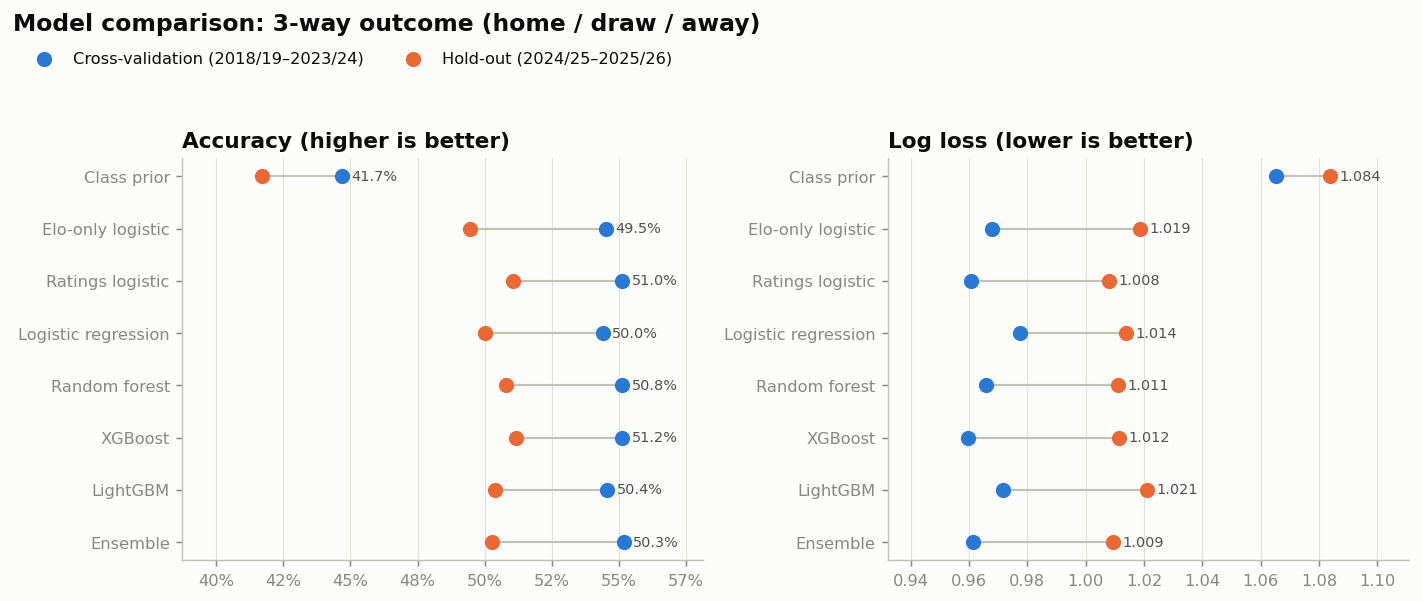

In [9]:
display(Image('../reports/figures/model_comparison.png'))

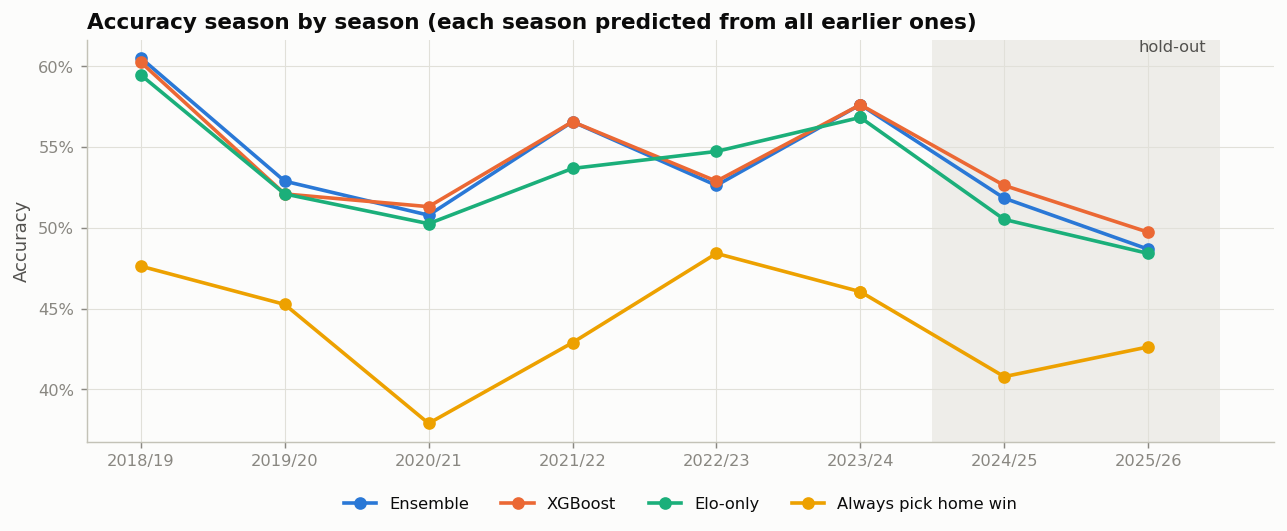

In [10]:
display(Image('../reports/figures/accuracy_by_season.png'))

### What the model gets right and wrong

The confusion matrix shows the classic football-prediction pattern: draws are almost never the *most likely* outcome
for any single match (they hover around 25–30%), so an accuracy-maximising classifier rarely picks them —
even though it assigns them sensible probabilities (see the calibration plot).

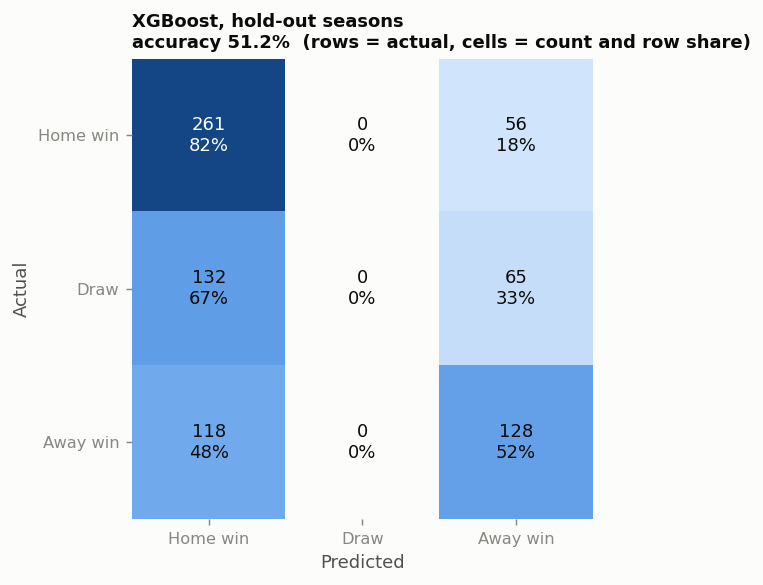

In [11]:
display(Image('../reports/figures/confusion_matrix_xgboost.png'))

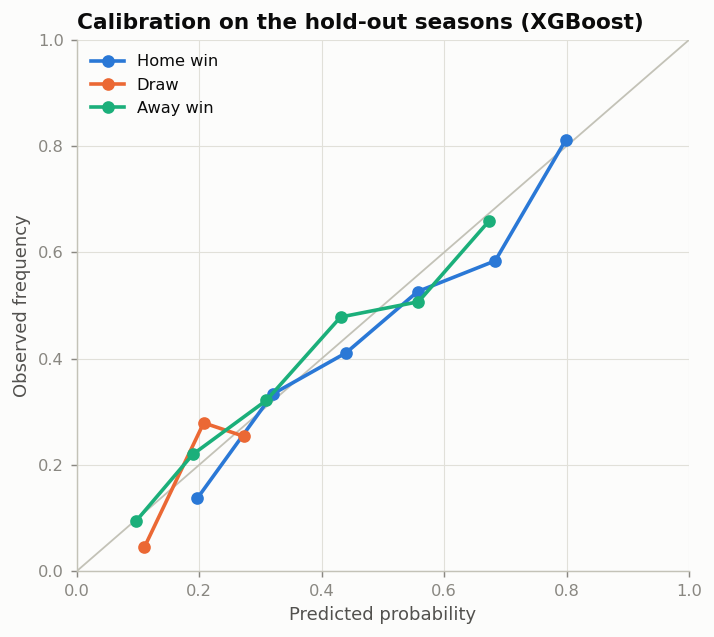

In [12]:
display(Image('../reports/figures/calibration_xgboost.png'))

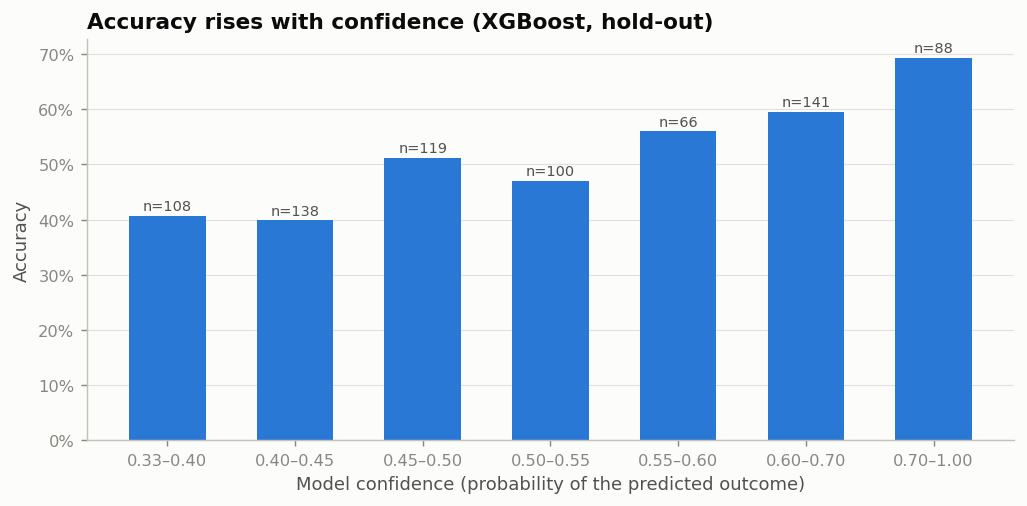

In [13]:
display(Image('../reports/figures/accuracy_by_confidence_xgboost.png'))

When the model is confident it is right much more often — the useful signal is in the probabilities, not just the label.

### Which features matter?

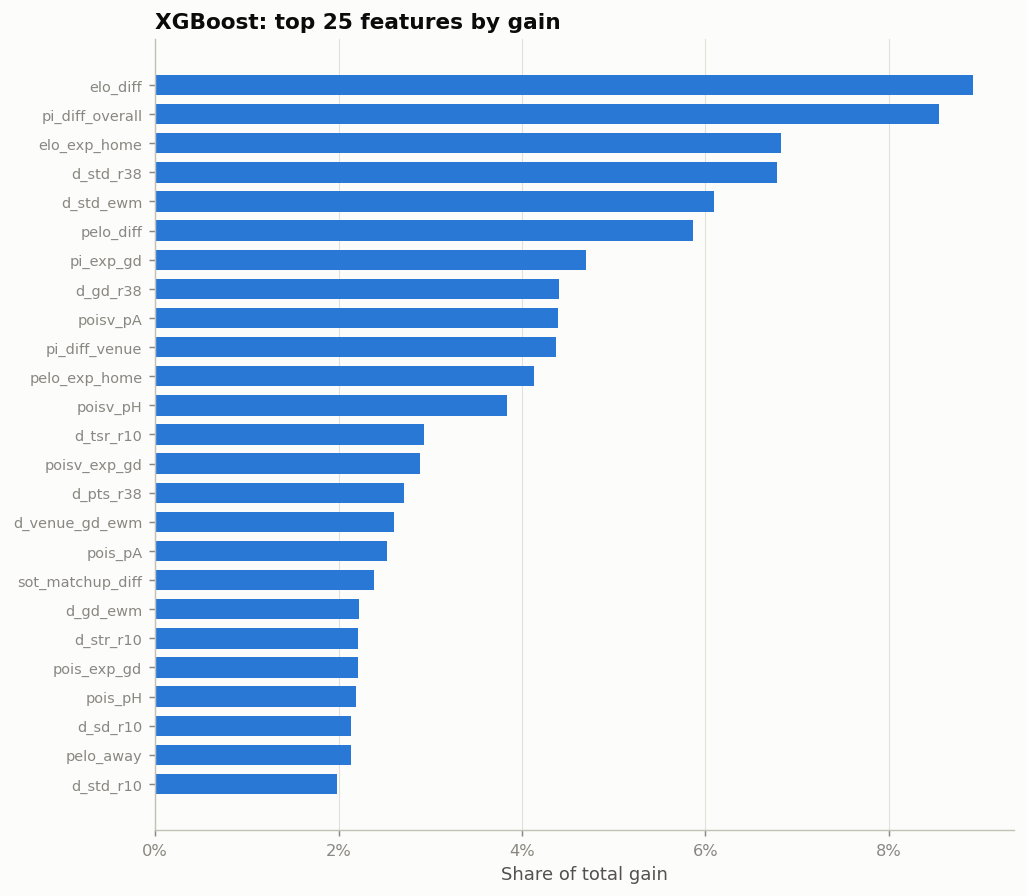

In [14]:
display(Image('../reports/figures/feature_importance_xgboost.png'))

## 4. A single cross-validation fold by hand

To see the machinery without the wrapper: train XGBoost on everything before 2023/24 and score that season.

In [15]:
from epl_predictor.train import load_dataset
from epl_predictor.models import make_xgb
from epl_predictor.metrics import evaluate_probs

ds = load_dataset()
season, tr, va = ds.folds[-1]
xgb_params = json.loads((Path.cwd().parent / "models" / "xgb_params.json").read_text())
model = make_xgb(xgb_params).fit(ds.X.iloc[tr], ds.y[tr])
probs = model.predict_proba(ds.X.iloc[va])
print(f"Season {season}/{(season+1)%100:02d}: trained on {len(tr):,} matches ->", {k: round(v, 4) for k, v in evaluate_probs(probs, ds.y[va]).items()})

Season 2023/24: trained on 7,980 matches -> {'accuracy': 0.5763, 'log_loss': 0.9246, 'brier': 0.5434, 'rps': 0.188}


## 5. Predict a fixture

`predict.py` appends the fixture to the match table with an unknown result, re-runs the feature pipeline
(so every rating and rolling stat is exactly what it would be on the eve of the match), and scores it with the deployed model.

In [16]:
from epl_predictor.predict import predict_fixtures, load_bundle, format_report

bundle = load_bundle()
fixtures = pd.DataFrame({
    "HomeTeam": ["Arsenal", "Man City", "Spurs", "Burnley"],
    "AwayTeam": ["Chelsea", "Liverpool", "Manchester United", "Everton"],
    "Date": ["2026-09-13"] * 4,
})
pred = predict_fixtures(fixtures, bundle, matches)
print(format_report(pred, bundle))
pred.round(3)

Model: xgboost  |  data through 2026-05-24

2026-09-13  Arsenal vs Chelsea
   home 64.6%   draw 23.1%   away 12.3%   ->  Home win (65%)
   Elo 1622 v 1522   expected goals 1.99 - 0.82

2026-09-13  Man City vs Liverpool
   home 61.2%   draw 23.1%   away 15.7%   ->  Home win (61%)
   Elo 1619 v 1587   expected goals 2.65 - 1.16

2026-09-13  Tottenham vs Man United
   home 26.9%   draw 26.7%   away 46.4%   ->  Away win (46%)
   Elo 1470 v 1536   expected goals 1.07 - 2.12

2026-09-13  Burnley vs Everton
   home 21.2%   draw 24.8%   away 53.9%   ->  Away win (54%)
   Elo 1404 v 1471   expected goals 0.79 - 1.51



,Date,HomeTeam,AwayTeam,P(home win),P(draw),P(away win),Prediction,Confidence,Elo home,Elo away,xG home,xG away
0,2026-09-13,Arsenal,Chelsea,0.646,0.231,0.123,Home win,0.646,1622.0,1522.0,1.99,0.82
1,2026-09-13,Man City,Liverpool,0.612,0.231,0.157,Home win,0.612,1619.0,1587.0,2.65,1.16
2,2026-09-13,Tottenham,Man United,0.269,0.267,0.464,Away win,0.464,1470.0,1536.0,1.07,2.12
3,2026-09-13,Burnley,Everton,0.212,0.248,0.539,Away win,0.539,1404.0,1471.0,0.79,1.51


## 6. Where to take it next

* **Better inputs beat better models here.** Possession, xG and lineup data (FBref / Understat / FPL) would add real signal;
  bookmaker odds even more so. The feature pipeline takes any extra per-match column.
* **Dixon–Coles** with time decay as a feature, or a Bayesian rating model.
* **Betting-style evaluation:** compare the probabilities to the closing odds and simulate a value-betting strategy.
* **Live season tracking:** once the 2026/27 file appears in the data mirror, `python run_pipeline.py --quick --refresh-data` retrains on it.